## Challenge 1: Feature extraction

1. **Definition:** Feature extraction is the transforming process of raw time series data into a set of informative and meaningful inputs or features that can be used by models to better understand patterns, predict future values, or detect structure in the data (Ciaburro et. al., 2021).

Instead of feeding the raw values directly, you extract new columns (features) that carry important information about trends, seasonality, change, etc (Dagum et al., 2016).

2. **Description:** Model’s Equations and Definitions
In time series feature extraction, we derive additional useful variables from the original data to improve model performance. Below are key features with their equations:

Lag Features
Capture prior values of the series:
\begin{equation}
\text{Lag}_k(y_t) = y_{t-k}
\end{equation}
where \( y_t \) is the number of passengers at time \( t \), and \( k \) is the lag order.

Where:

𝑦𝑡 is the number of passengers at time 𝑡

𝑘 is the lag order


Rolling Mean (Moving Average)
Smooths short-term fluctuations:

\begin{equation}
\text{RollingMean}_w(y_t) = \frac{1}{w} \sum_{i=0}^{w-1} y_{t-i}
\end{equation}


where \( w \) is the window size and \( y_{t-i} \) is the \( i \)-th previous value in the window.



Rolling Standard Deviation
Captures variability in a window:

\begin{equation}
\text{RollingStd}_w(y_t) = \sqrt{ \frac{1}{w - 1} \sum_{i=0}^{w-1} (y_{t-i} - \text{RollingMean}_w(y_t))^2 }
\end{equation}

This captures the variability in the \( w \)-sized moving window.


First Order Differencing
Helps remove trend and achieve stationarity:

\begin{equation}
\text{Diff}_1(y_t) = y_t - y_{t-1}
\end{equation}
This transformation removes trend and helps achieve stationarity.

3. **Demonstration:** A Simple Public Dataset (Good for Practice & Projects) is used monthly international airline passengers(1949–1960) Which is available in Python via statsmodels.

In [50]:
from statsmodels.datasets import get_rdataset
import pandas as pd
import matplotlib.pyplot as plt

# Load AirPassengers data
data = get_rdataset("AirPassengers", package="datasets").data
data['Month'] = pd.date_range(start="1949-01-01", periods=len(data), freq='M')
data.set_index('Month', inplace=True)
data.rename(columns={'value': 'Passengers'}, inplace=True)

# Feature extraction
data['Lag_1'] = data['Passengers'].shift(1)
data['Lag_12'] = data['Passengers'].shift(12)  # yearly seasonality
data['RollingMean_3'] = data['Passengers'].rolling(window=3).mean()
data['RollingStd_3'] = data['Passengers'].rolling(window=3).std()
data['Diff_1'] = data['Passengers'].diff()

# Drop missing values created by lag/rolling
data_clean = data.dropna()

<ipython-input-50-1c1087c01652>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data['Month'] = pd.date_range(start="1949-01-01", periods=len(data), freq='M')


4. **Diagram**

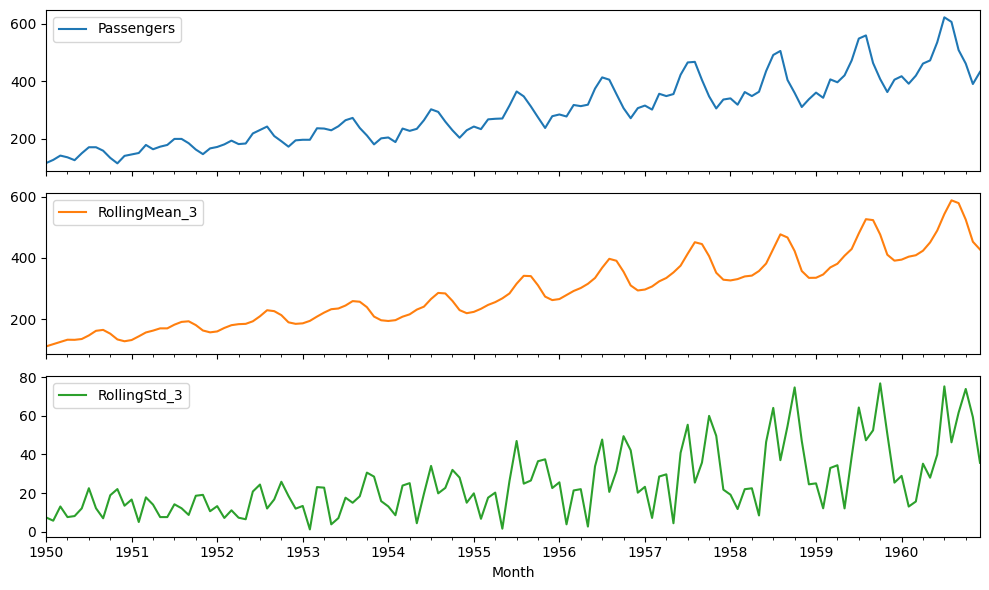

In [51]:
# Visualize extracted features
data_clean[['Passengers', 'RollingMean_3', 'RollingStd_3']].plot(subplots=True, figsize=(10, 6)) # Changed 'df_cleaned' to 'data_clean' and column names to the ones created in previous cell.
plt.tight_layout()
plt.show()

5. **Diagnosis**: Diagnosis of feature extraction entails determining whether the features extracted from raw data are valuable for a machine learning model’s performance. Usually, it begins by understanding the type of data that is extracted methodically and their features using tools like PCA, t-SNE, or UMAP to understand if the features can capture some separable structure. In order to evaluate the contribution of the features on the prediction, simple models have to be trained and feature importance metrics must be evaluated. Correlation matrices can help identify redundant and multicollinearity features and remove uninformative features based on variance threshold. Features which do not seem likely to be significantly related to the target variable can be tested using statistical tests like ANOVA or chi-square. Ablation studies can identify which features are most important and cross validation ensures that the features generalise well to new data. Last, sanity checks—shuffling the target variable, or injecting noise—confirm that indeed the features captured are indeed carrying useful signal or not.

6. **Damage**: The original dataset was highly non-stationary, making it hard to model.
Without transformation, any time series model would likely give misleading for for yearly trends
Rolling statistics reduced noise but may remove critical short-term signals.
Missing values were introduced due to lagging and rolling operations.
Some extracted features may be redundant or poorly timed if not tuned.


7. **Directions**: Explore alternative window sizes (e.g., 6 or 12 months) to capture longer cycles.
Try seasonal differencing (like 𝑦𝑡−𝑦𝑡−12)for yearly trends.
Test additional features like percentage change, exponential smoothing, or holidays.
Apply dimensionality reduction (e.g., PCA) if too many features are generated.
Experiment with combining features in ML models like Random Forest or XGBoost.


8. **Deployment**: The extracted features can be fed into supervised learning or forecasting models.
Airlines or airports could use the forecasts to plan staff or resources.
Features like lags and rolling stats can be updated dynamically each month.
This setup can be automated in Python notebooks or production pipelines.
Models built on these features offer better accuracy and operational value.



## Challenge 2: Modeling Non-Stationarity & Finding an Equilibrium

1. **Definition**: A time series is stationary if its statistical properties, such as mean and variance, do not change over time.
The presence of a **unit root** indicates non-stationarity.
The Augmented Dickey-Fuller (ADF) test is used to check for stationarity:

$$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + \epsilon_t$$

- If $\gamma = 0 $, the series has a unit root and is non-stationary.
- If $\gamma < 0 $, the series is stationary.


2. **Description**: A non-stationary series has trends, changing variances, or seasonality, which can lead to misleading statistical inferences. Many financial time series exhibit non-stationarity, requiring transformation techniques.

In [52]:
!pip install arch

In [53]:
# Load packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from arch.unitroot import ADF, KPSS
from arch.unitroot.cointegration import phillips_ouliaris
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import UECM
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (16, 9)  # Figure size and width

In [54]:
# Download datasets
data = pd.read_csv("Gold_Silver_Platinum_Historical_Price_USD.csv")

# Convert date variable to date format and set index
data["Date2"] = pd.to_datetime(data["Date"], format="%Y/%m/%d")
data_set = data.loc[:,].set_index("Date2")
gold = data.loc[:, ["Date2", "Gold"]].set_index("Date2")
silver = data.loc[:, ["Date2", "Silver"]].set_index("Date2")
platinum = data.loc[:, ["Date2", "Platinum"]].set_index("Date2")
data_set.head()


# Selecting Gold, Platinum, and Silver Prices
# gold = data_set.Gold
# platinum = data_set.Platinum
# silver = data_set.Silver

,Date,Gold,Silver,Platinum
Date2,,,,
1985-01-28,1985/01/28,297.7,6.08,270.0
1985-01-29,1985/01/29,303.2,6.23,271.5
1985-01-30,1985/01/30,302.9,6.21,272.5
1985-01-31,1985/01/31,306.6,6.37,283.0
1985-02-01,1985/02/01,303.6,6.23,277.0


3. **Demonstration**:

In [55]:
gold.head()

,Gold
Date2,
1985-01-28,297.7
1985-01-29,303.2
1985-01-30,302.9
1985-01-31,306.6
1985-02-01,303.6


In [56]:
print(gold.isna().sum())      # Check missing values
print(gold.describe())        # Check for very low variance (possibly constant)

Gold    0
dtype: int64
               Gold
count  10175.000000
mean     816.723046
std      558.941817
min      252.300000
25%      357.987000
50%      447.194000
75%     1281.304950
max     2299.170200


In [57]:
gold = gold.dropna().astype(float)

In [58]:
print(gold.isna().sum())      # Check missing values
print(gold.describe())        # Check for very low variance (possibly constant)

Gold    0
dtype: int64
               Gold
count  10175.000000
mean     816.723046
std      558.941817
min      252.300000
25%      357.987000
50%      447.194000
75%     1281.304950
max     2299.170200


Figure 1: Gold Price Plot from 1985 to 2024

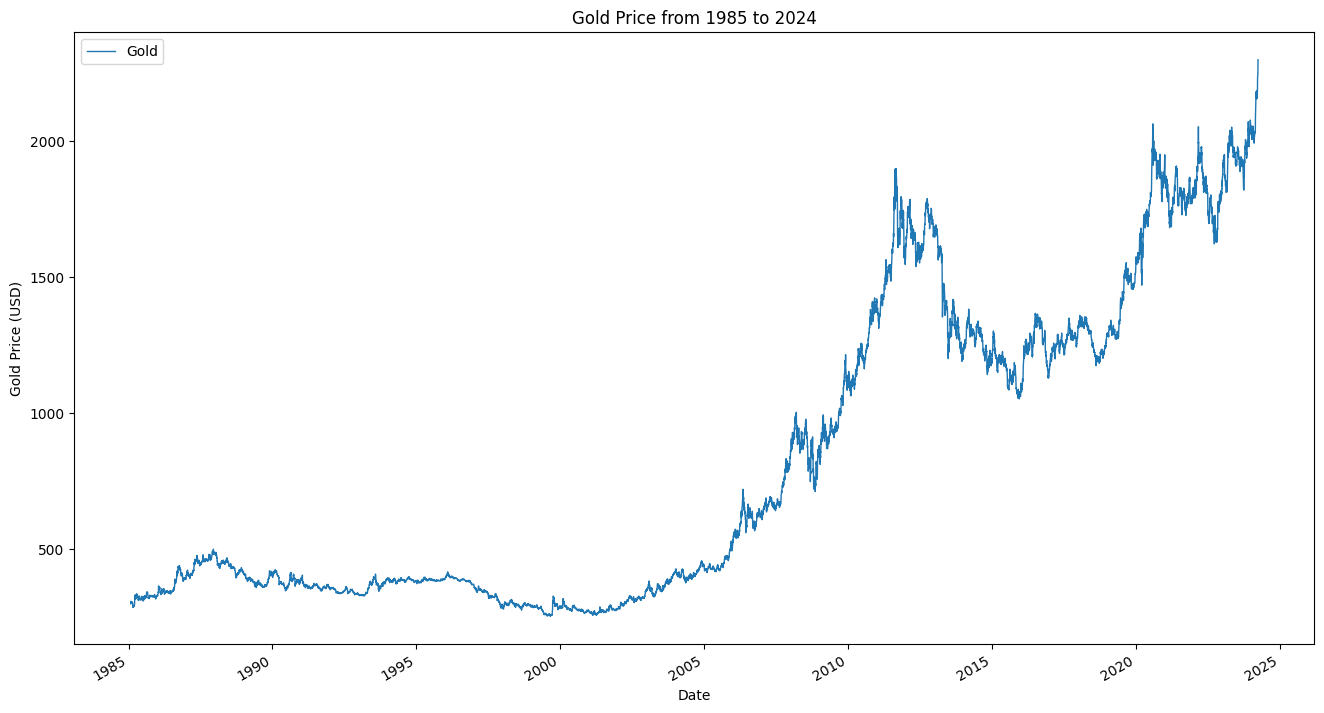

In [59]:
gold.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Gold Price (USD)",
    title="Gold Price from 1985 to 2024",
)
plt.show()

In **Figure 1** above, the gold price appears to be increasing at an exponential rate. Below, we test for non-stationarity by doing three versions of the ADF and KPSS tests and see the results.

4. **Diagnosis**: First, we test for non-stationarity by doing the ADF without drift and trend.
**Figure 2: Gold Price, ADF Test without Drift and Trend**

In [60]:
# Gold Price, ADF Test without Drift and Trend
adf_none = ADF(gold, trend="n", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_none.regression.summary())
print("\nTest statistics and critical values: \n", adf_none)

# result = adfuller(gold.dropna(), maxlag=1, regression='nc')
# print(f"ADF Statistic: {result[0]}")
# print(f"p-value: {result[1]}")
# print(f"Critical Values: {result[4]}")

Augmented Dickey-Fuller Unit Root Test
                                  OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              4.495
Date:                Tue, 08 Apr 2025   Prob (F-statistic):                      0.0340
Time:                        23:50:17   Log-Likelihood:                         -37777.
No. Observations:               10174   AIC:                                  7.556e+04
Df Residuals:                   10173   BIC:                                  7.556e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-

In **Figure 2** above, we see that the ADF test's statistic is 2.120. The 5% critical value is -1.94. Hence, we cannot reject $H_0$. The conclusion is that there is a unit root in the gold price.

Next, we test for non-stationarity by doing the ADF test with drift but no trend.

**Figure 3: Gold Price, ADF Test with Drift but No Trend**

In [61]:
# ADF test with drift but no trend
adf_drift = ADF(gold, trend="c", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_drift.regression.summary())
print("\nTest statistics and critical values: \n", adf_drift)

Augmented Dickey-Fuller Unit Root Test
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6892
Date:                Tue, 08 Apr 2025   Prob (F-statistic):              0.406
Time:                        23:50:17   Log-Likelihood:                -37777.
No. Observations:               10174   AIC:                         7.556e+04
Df Residuals:                   10172   BIC:                         7.557e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Level.L1    

In **Figure 3** above, we see that the ADF test statistic is 0.830, and the 5% critical value is -2.86. Hence, we cannot reject $H_0$ that there is a unit root. The conclusion is that we have a unit root and a drift in the gold price.

Last, we test for non-stationarity by doing the ADF test with drift and trend.

**Figure 4: Gold Price, ADF Test with Drift and Trend**

In [62]:
# ADF test with drift and trend
adf_trend = ADF(gold, trend="ct", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", adf_trend.regression.summary())
print("\nTest statistics and critical values: \n", adf_trend)

Augmented Dickey-Fuller Unit Root Test
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.210
Date:                Tue, 08 Apr 2025   Prob (F-statistic):              0.110
Time:                        23:50:17   Log-Likelihood:                -37775.
No. Observations:               10174   AIC:                         7.556e+04
Df Residuals:                   10171   BIC:                         7.558e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Level.L1    

In **Figure 4** above, we see that the ADF test statistic is -1.279, and the 5% critical value is -3.41. Hence, we cannot reject $H_0$ that there is a unit root. The conclusion is that we have a unit root, a drift, but no time trend in the gold price.

Now, we want to see the result we will get when we run a KPSS test below.

**Figure 5: Gold Price, KPSS Test**

In [63]:
# KPSS test
# (Set lags=-1 to use the old method that only depends on the sample size)
print(KPSS(gold, trend="ct", lags=-1))

    KPSS Stationarity Test Results   
Test Statistic                  3.770
P-value                         0.000
Lags                               39
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


In **Figure 5** above, we can see that the $p$-value is smaller than 5%. This means that we reject $H_0$. The conclusion is that the gold price is not trend stationary and has a unit root.

From the above analysis, we can see for ourselves that the gold price follows a random walk with a drift model.

Having concluded that the gold price time series is non-stationary after the ADF test and/or the KPSS test, we are taking the necessary steps to make it stationary. That is, we do the log difference transformation and then check the new time series again with the ADF test and/or the KPSS test.

In **Figure 6** below, we show the plot of the gold price with log difference transformation.

**Figure 6: Plot of Logged Difference of the Gold Price from 1985 to 2024**

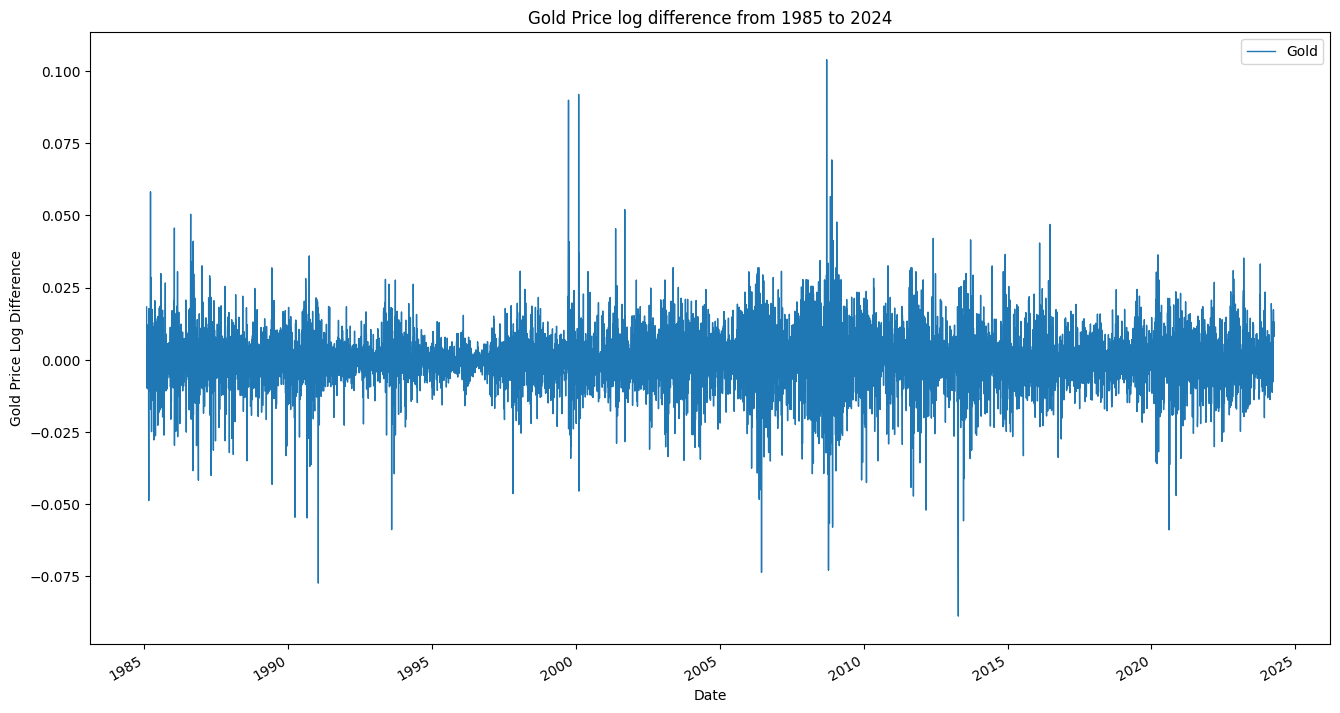

In [64]:
# Plot gold price log difference time series chart
lgold = np.log(gold).diff().dropna()
lgold.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Gold Price Log Difference",
    title="Gold Price log difference from 1985 to 2024",
)
plt.show()

We run the three versions of an ADF test for the logged difference of the gold price in **Figure 7** below. For our purposes here, we are only interested in the ADF test statistics and 5% critical values for the three models.

**Figure 7: Three Versions of ADF Test for Logged Difference of Gold Price**

In [65]:
# Three ADF Tests for logged difference of the gold price
print("Gold Price Log Difference with no Drift no Trend")
print(ADF(lgold, trend="n", method="bic"))
# adf_test(lgold, regression='n')

print("\n\nGold Price Log Difference with Drift")
print(ADF(lgold, trend="c", method="bic"))
# adf_test(lgold, regression='c')

print("\n\nGold Price Log Difference with Drift and Trend")
print(ADF(lgold, trend="ct", method="bic"))
# adf_test(lgold, regression='ct')

Gold Price Log Difference with no Drift no Trend
   Augmented Dickey-Fuller Results   
Test Statistic               -102.092
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Gold Price Log Difference with Drift
   Augmented Dickey-Fuller Results   
Test Statistic               -102.131
P-value                         0.000
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Gold Price Log Difference with Drift and Trend
   Augmented Dickey-Fuller Results   
Test Statistic               -102.134
P-value                         0.000
Lags       

In **Figure 7** above, we can see that there is no unit root for the logged difference of the gold price. We run the KPSS test for the logged difference of the gold price in **Figure 8** below.

**Figure 8: KPSS Test for Logged Difference of the Gold Price**

In [66]:
# KPSS test
# (Set lags=-1 to use the old method that only depends on the sample size)
print(KPSS(lgold, trend="ct", lags=-1))

    KPSS Stationarity Test Results   
Test Statistic                  0.104
P-value                         0.148
Lags                               39
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


In **Figure 8** above, we can see that the KPSS test cannot reject $H_0$, and we can conclude that there is no unit root and the logged difference of the gold price is stationary.

In [67]:
print(platinum.isna().sum())      # Check missing values
print(platinum.describe())        # Check for very low variance (possibly constant)

Platinum    0
dtype: int64
           Platinum
count  10175.000000
mean     822.028127
std      425.549354
min      243.000000
25%      426.000000
50%      813.000000
75%     1064.000000
max     2240.000000


In [68]:
platinum = platinum.dropna().astype(float)

In [69]:
print(platinum.isna().sum())      # Check missing values
print(platinum.describe())        # Check for very low variance (possibly constant)

Platinum    0
dtype: int64
           Platinum
count  10175.000000
mean     822.028127
std      425.549354
min      243.000000
25%      426.000000
50%      813.000000
75%     1064.000000
max     2240.000000


**Figure 9: Platinum Price Plot from 1985 to 2024**

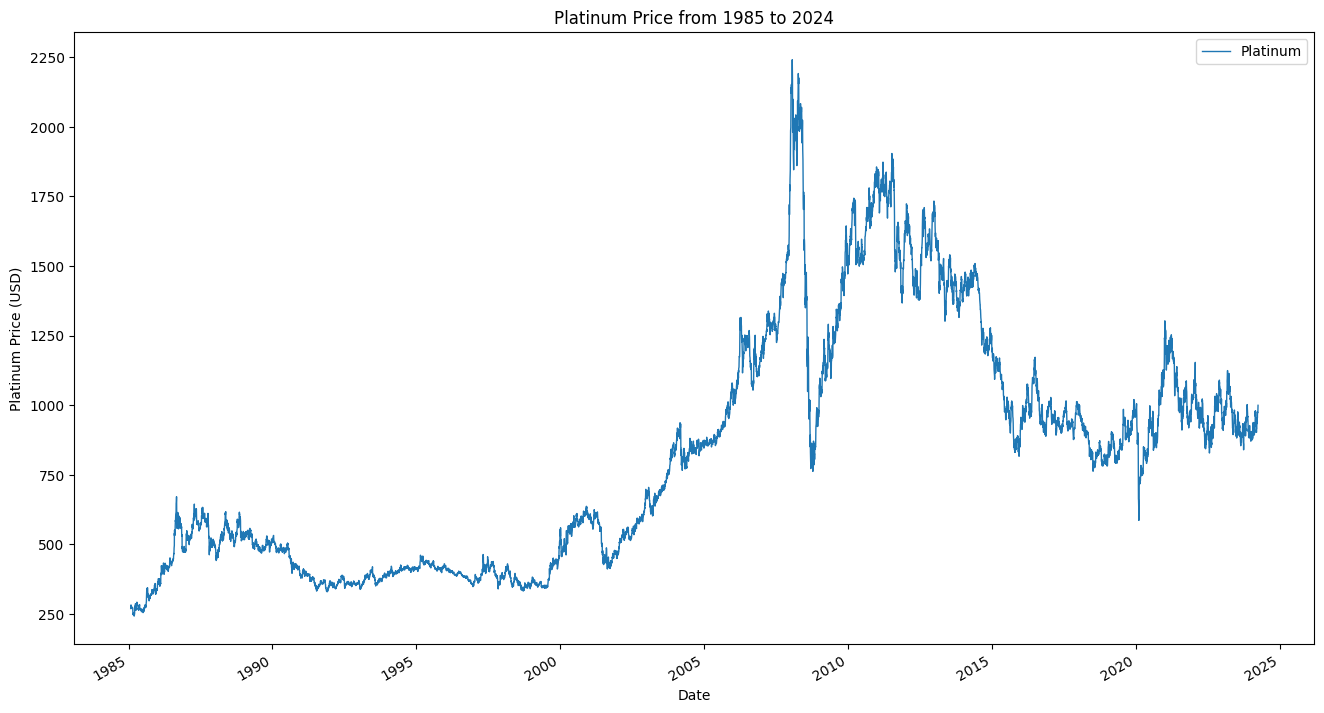

In [70]:
platinum.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Platinum Price (USD)",
    title="Platinum Price from 1985 to 2024",
)
plt.show()

**Figure 10: Plot of Logged Difference of the Platinum Price from 1985 to 2024**

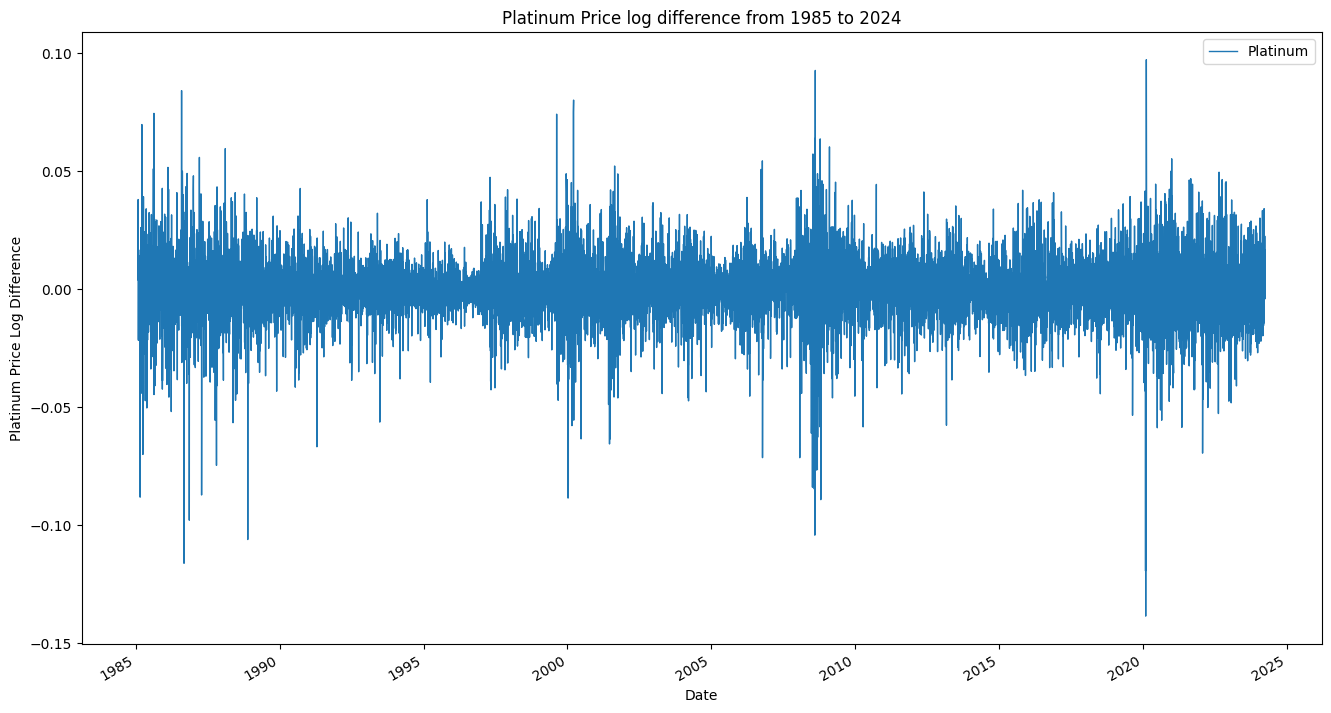

In [71]:
# Plot platinum price log difference time series chart
lplatinum = np.log(platinum).diff().dropna()
lplatinum.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Platinum Price Log Difference",
    title="Platinum Price log difference from 1985 to 2024",
)
plt.show()

**Figure 11: Three Versions of ADF Test for Logged Difference of Platinum Price**

In [72]:
# Three ADF Tests for logged difference of the gold price
print("Platinum Price Log Difference with no Drift no Trend")
print(ADF(lplatinum, trend="n", method="bic"))
# adf_test(lplatinum, regression='n')

print("\n\nPlatinum Price Log Difference with Drift")
print(ADF(lplatinum, trend="c", method="bic"))
# adf_test(lplatinum, regression='c')

print("\n\nPlatinum Price Log Difference with Drift and Trend")
print(ADF(lplatinum, trend="ct", method="bic"))
# adf_test(lplatinum, regression='ct')

Platinum Price Log Difference with no Drift no Trend
   Augmented Dickey-Fuller Results   
Test Statistic                -98.633
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Platinum Price Log Difference with Drift
   Augmented Dickey-Fuller Results   
Test Statistic                -98.635
P-value                         0.000
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Platinum Price Log Difference with Drift and Trend
   Augmented Dickey-Fuller Results   
Test Statistic                -98.636
P-value                         0.000

In **Figure 11** above, we can see that there is no unit root for the logged difference of the platinum price. We run the KPSS test for the logged difference of the platinum price in **Figure 12** below.

**Figure 12: KPSS Test for Logged Difference of the Platinum Price**

In [73]:
# KPSS test
# (Set lags=-1 to use the old method that only depends on the sample size)
print(KPSS(lplatinum, trend="ct", lags=-1))

    KPSS Stationarity Test Results   
Test Statistic                  0.055
P-value                         0.507
Lags                               39
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


In **Figure 12** above, we can see that the KPSS test cannot reject $H_0$, and we can conclude that there is no unit root and the logged difference of the platinum price is stationary.

In [74]:
print(silver.isna().sum())      # Check missing values
print(silver.describe())        # Check for very low variance (possibly constant)

Silver    0
dtype: int64
             Silver
count  10175.000000
mean      12.097693
std        8.532668
min        3.530000
25%        5.103200
50%        7.180000
75%       17.460000
max       48.410000


In [75]:
silver = silver.dropna().astype(float)

In [76]:
print(silver.isna().sum())      # Check missing values
print(silver.describe())        # Check for very low variance (possibly constant)

Silver    0
dtype: int64
             Silver
count  10175.000000
mean      12.097693
std        8.532668
min        3.530000
25%        5.103200
50%        7.180000
75%       17.460000
max       48.410000


**Figure 13: Time Plots of the Gold, Platinum, and Silver Prices**

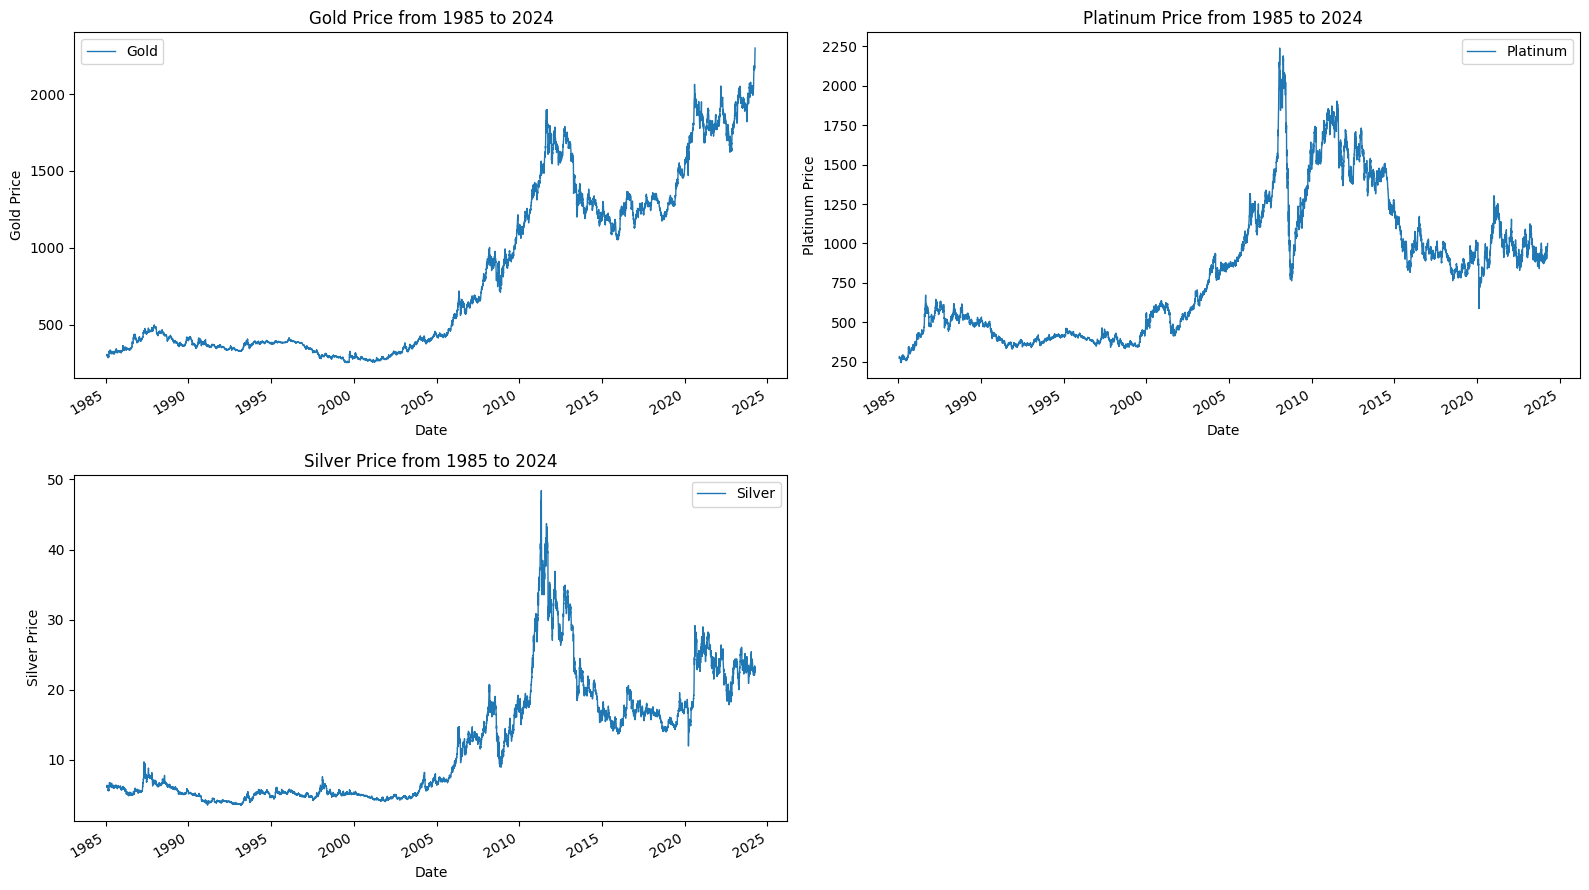

In [77]:
# Time plots for the gold, platinum, and silver prices
fig, axs = plt.subplots(2, 2)

gold.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Gold Price",
    title="Gold Price from 1985 to 2024",
    ax=axs[0, 0],
)

platinum.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Platinum Price",
    title="Platinum Price from 1985 to 2024",
    ax=axs[0, 1],
)

silver.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Silver Price",
    title="Silver Price from 1985 to 2024",
    ax=axs[1, 0],
)

axs[1, 1].axis("off")
fig.tight_layout()
plt.show()

**Figure 14: ADF Test Results with 5% Significance Level for the Gold, Platinum and Silver Prices**

In [78]:
# ADF Test Results with 5% Significance Level for Gold, Platinum, and Silver prices
gold_adf = ADF(gold, trend="n", method="bic")
platinum_adf = ADF(platinum, trend="n", method="bic")
silver_adf = ADF(silver, trend="n", method="bic")

pd.DataFrame(
    {
        "Gold Price": (gold_adf.stat, gold_adf.critical_values["5%"]),
        "| Platinum Price": (platinum_adf.stat, platinum_adf.critical_values["5%"]),
        "| Silver Price": (
            silver_adf.stat,
            silver_adf.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Gold Price,| Platinum Price,| Silver Price
ADF Test Statistic,2.120195,-0.426899,-0.496594
5% Critical Value,-1.941026,-1.941026,-1.941026


In **Figure 14** above, we can see that none of the precious metals has an ADF test statistic lower than the 5% critical value. Hence, we cannot reject $H_0$ hypothesis. Therefore, there are unit roots in the three time series. We take the log differences of the three time series in **Figure 15** and test the log differenced time series again in **Figure 16** below.

**Figure 15: Time Plots for Log Differenced Gold, Platinum, and Silver Prices from 1985 to 2024**

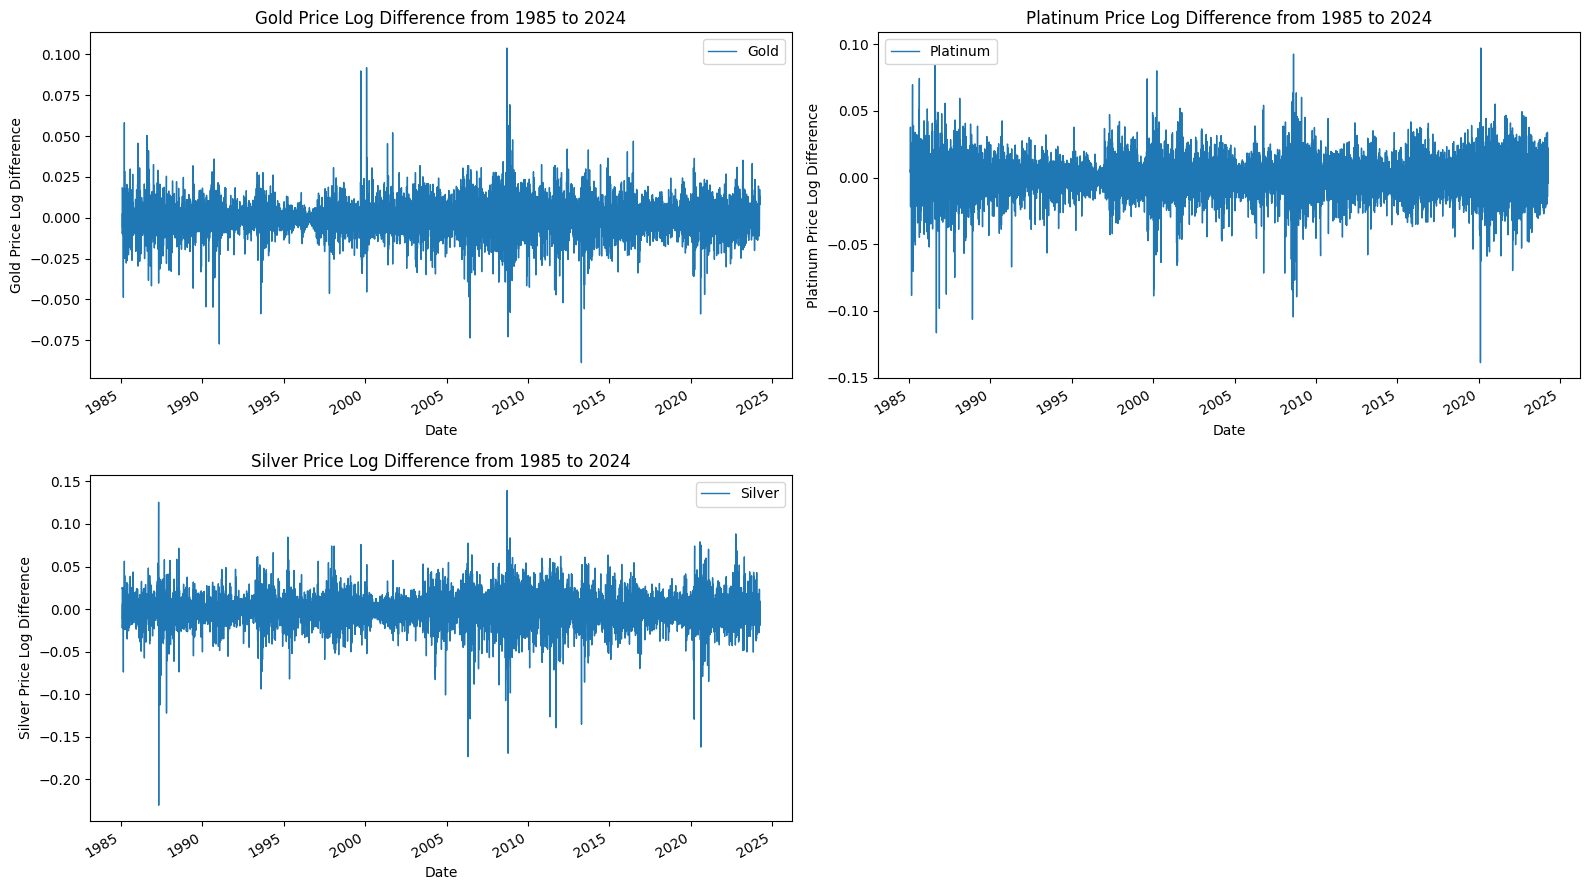

In [79]:
# Time Plots for Log Differenced Gold, Platinum, and Silver Prices
fig, axs = plt.subplots(2, 2)

lgold = np.log(gold).diff().dropna()
lgold.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Gold Price Log Difference",
    title="Gold Price Log Difference from 1985 to 2024",
    ax=axs[0, 0],
)

lplatinum = np.log(platinum).diff().dropna()
lplatinum.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Platinum Price Log Difference",
    title="Platinum Price Log Difference from 1985 to 2024",
    ax=axs[0, 1],
)

lsilver = np.log(silver).diff().dropna()
lsilver.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Silver Price Log Difference",
    title="Silver Price Log Difference from 1985 to 2024",
    ax=axs[1, 0],
)

axs[1, 1].axis("off")
fig.tight_layout()
plt.show()

**Figure 16: ADF Test Results with 5% Significance Level for Differenced Gold, Platinum, and Silver Prices**

In [80]:
# ADF Test Results with 5% Significance Level for Log Differenced Gold, Platinum, and Silver Prices
lgold_adf = ADF(lgold, trend="n", method="bic")
lplatinum_adf = ADF(lplatinum, trend="n", method="bic")
lsilver_adf = ADF(lsilver, trend="n", method="bic")

pd.DataFrame(
    {
        "Gold Price": (lgold_adf.stat, lgold_adf.critical_values["5%"]),
        "| Platinum Price": (lplatinum_adf.stat, lplatinum_adf.critical_values["5%"]),
        "| Silver Price": (
            lsilver_adf.stat,
            lsilver_adf.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Gold Price,| Platinum Price,| Silver Price
ADF Test Statistic,-102.092445,-98.632696,-101.243439
5% Critical Value,-1.941026,-1.941026,-1.941026


In **Figure 16** above, we can see the ADF test statistics for the three time series are all lower than the 5% critical value. Therefore, we can conclude that we can reject $H_0$ hypothesis and state that the three log differenced time series do not have unit roots.

The next thing we need to do is to decide how many lags we would like to include in our VAR model for the gold, platinum, and silver prices. Using the information criteria, the number of lags for the VAR model is selected automatically for us. In **Figure 17** below, we show the result of selecting the optimal number of lags for the log differences of the three time series.

**Figure 17: VAR Model Lag Selection for Log Differenced Gold, Platinum, and Silver Prices**

In [81]:
# VAR Model Lag Selection for Log Differenced Gold, Platinum, and Silver Prices

# Join log time series in one DataFrame
diff_data = pd.concat([lgold, lplatinum, lsilver], axis=1)

# Fit VAR model and run lag selection tool
model = VAR(diff_data)
x = model.select_order(maxlags=12, trend="c")
x.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-25.84,-25.84,5.983e-12,-25.84
1,-25.84,-25.83,5.981e-12,-25.84
2,-25.86,-25.84,5.896e-12,-25.85
3,-25.97,-25.94,5.291e-12,-25.96
4,-25.99,-25.96,5.171e-12,-25.98
5,-26.01,-25.97*,5.072e-12,-26.00
6,-26.01*,-25.97,5.053e-12*,-26.00*
7,-26.01,-25.96,5.059e-12,-25.99
8,-26.01,-25.96,5.061e-12,-25.99
9,-26.01,-25.95,5.066e-12,-25.99


In **Figure 17**, we can see different information criteria gives different results. For selecting the optimal number of lags, there are many options from 0 to 12 lags. We can run one set of a VAR model with one lag and one set of a VAR model with nine lags and then compare the model results and select the optimal one. We are going to select only one lag, i.e., run the VAR(1) model for the difference of the gold, platinum, and silver prices in **Figure 18** below. Also, we will include an intercept in our model.

**Figure 18: VAR(1) Model Result for Differenced Gold, Platinum, and Silver Prices**

In [82]:
# VAR(1) model for Differenced Gold, Platinum, and Silver Prices
diff_mod = VAR(diff_data)
diff_mod_var = diff_mod.fit(
    maxlags=None,
    # when maxlags=None criterion to use for VAR order selection is
    # ic{'aic', 'fpe', 'hqic', 'bic', None}
    ic=None,  # ic=None => automatic lag selection
    method="ols",
    trend="c",
    verbose=True,
)
diff_mod_var.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 08, Apr, 2025
Time:                     23:50:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.8347
Nobs:                     10173.0    HQIC:                  -25.8403
Log likelihood:           88159.0    FPE:                5.97627e-12
AIC:                     -25.8432    Det(Omega_mle):     5.96923e-12
--------------------------------------------------------------------
Results for equation Gold
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000203         0.000097            2.103           0.035
L1.Gold            -0.012153         0.009916           -1.226           0.220
L1.Platinum        -0.007915         0.006713           -1.179       

In [83]:
# Get the lag order that was selected
lag_order = diff_mod_var.k_ar
print(lag_order)

1


**Figure 18** lists out the coefficient estimates for three equations. For the Gold (GOLDUSD) equation, the constant is significant. For the Platinum (PLATINUMUSD) equation, Gold lag 1 and Platinum lag 1 are significant. For the Silver (SILVERUSD) equation, Gold lag 1 is significant. We do the forecast plots from the model in **Figure 19** below.

**Figure 19: VAR Model Forecast of the Difference of the Log Differenced Gold, Platinum, and Silver Prices**

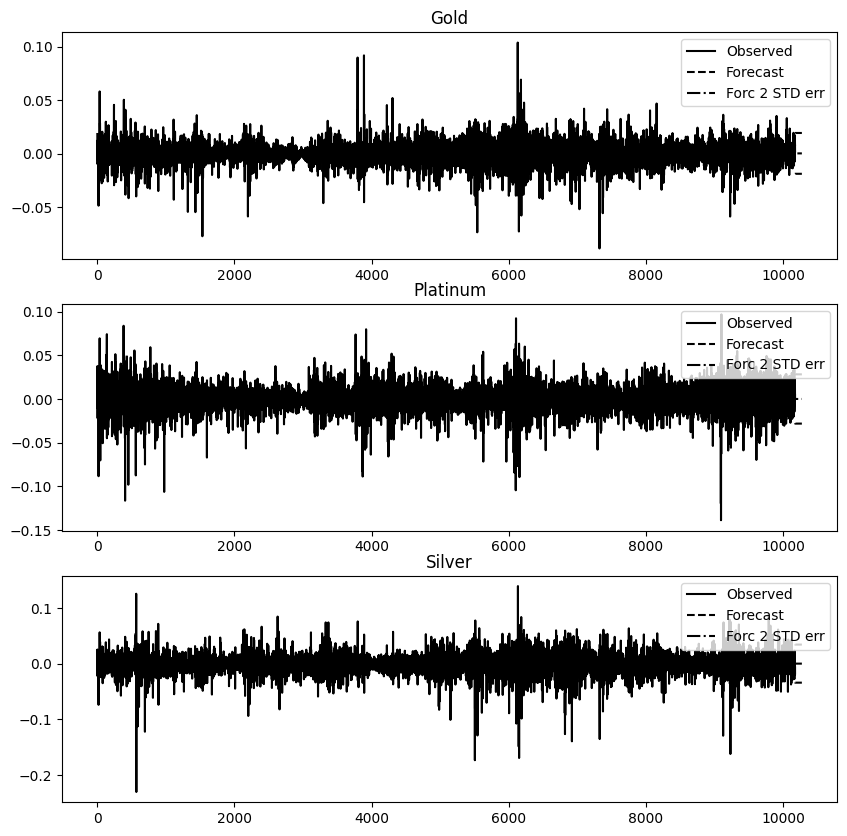

In [84]:
# VAR Model Forecast of the Difference of the Log Differenced Gold, Platinum, and Silver Prices
diff_mod_var.plot_forecast(steps=100, alpha=0.05, plot_stderr=True)
plt.show()

**Figure 20: VAR Model Forecast of Level of Gold, Platinum, and Silver Prices**

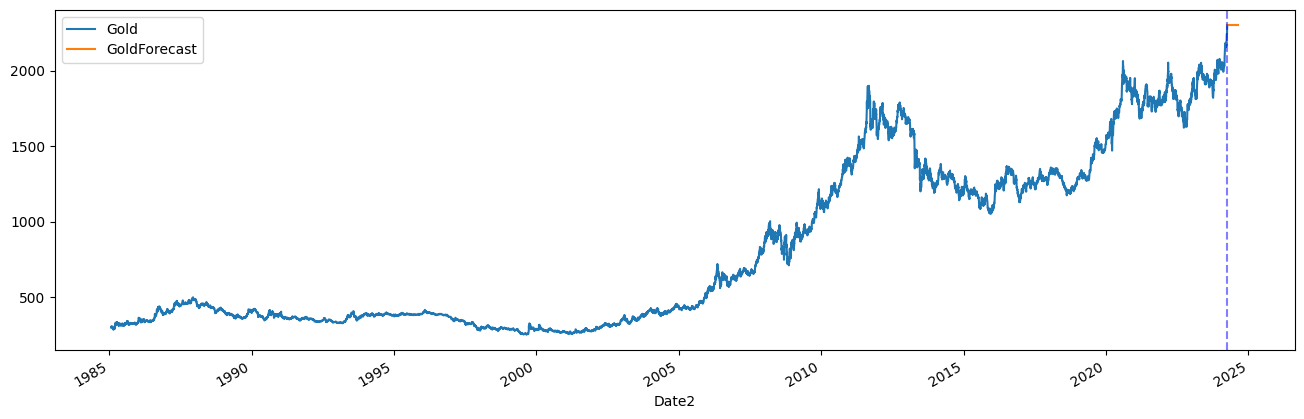

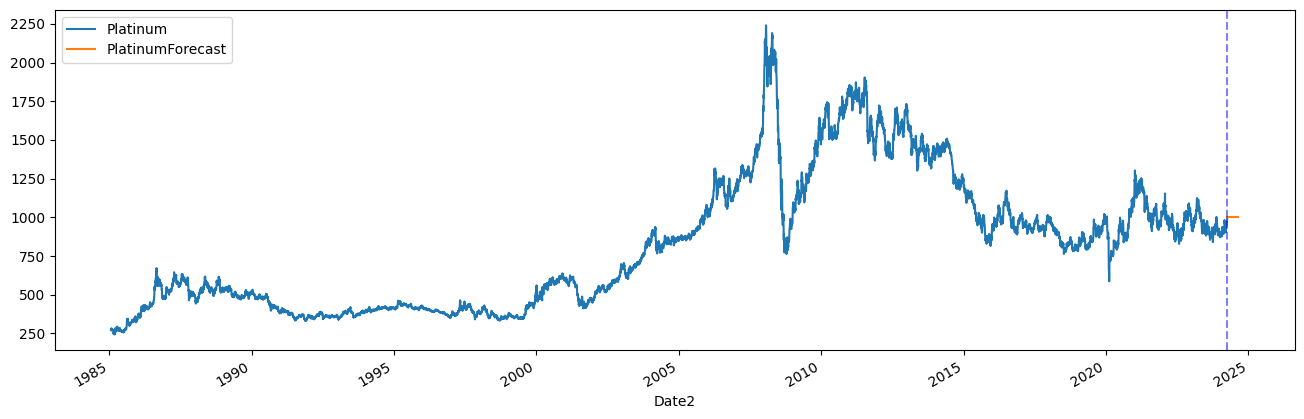

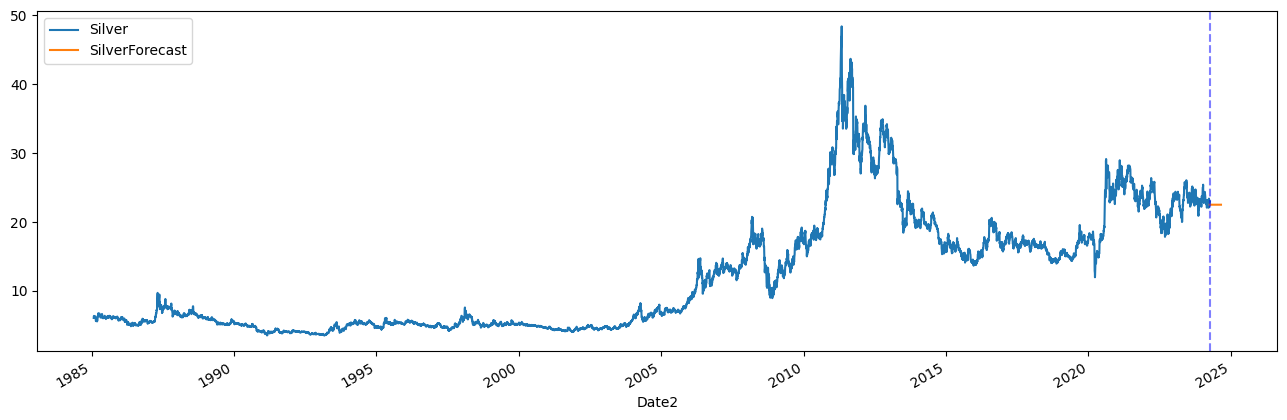

In [85]:
# VAR Model Forecast of Level of Gold, Platinum, and Silver Prices

# get 100 step prediction values for differenced data
# drop NA values at start
diff_data_val = diff_data.values[diff_mod_var.k_ar :]  # noQA E203
pred = diff_mod_var.forecast(y=diff_data_val, steps=100)
pd.DataFrame(pred)

# extend index with 100 more business dates per USFederalHolidayCalendar
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
idx = pd.date_range("2024-04-04", periods=100, freq=us_bd)
df_forecast = pd.DataFrame(
    data=pred, index=idx, columns=["Gold1d", "Platinum1d", "Silver1d"]
)

# recover/re-align lagged predicted values to get forecasts at original dates
df_forecast["GoldForecast"] = data_set["Gold"].iloc[-1] + df_forecast["Gold1d"]
df_forecast["PlatinumForecast"] = data_set["Platinum"].iloc[-1] + df_forecast["Platinum1d"]
df_forecast["SilverForecast"] = data_set["Silver"].iloc[-1] + df_forecast["Silver1d"]


# plot initial data with forecasted values for each of Gold, Platinum, and Silver Prices
data_set["Gold"].plot(figsize=(16, 5), legend=True)
df_forecast["GoldForecast"].plot(legend=True)
plt.axvline(x="2024-04-04", color="b", alpha=0.5, linestyle="--")
plt.show()

data_set["Platinum"].plot(figsize=(16, 5), legend=True)
df_forecast["PlatinumForecast"].plot(legend=True)
plt.axvline(x="2024-04-04", color="b", alpha=0.5, linestyle="--")
plt.show()

data_set["Silver"].plot(figsize=(16, 5), legend=True)
df_forecast["SilverForecast"].plot(legend=True)
plt.axvline(x="2024-04-04", color="b", alpha=0.5, linestyle="--")
plt.show()

**Figure 21: Gold and Platinum Plot from 1985 to 2024**

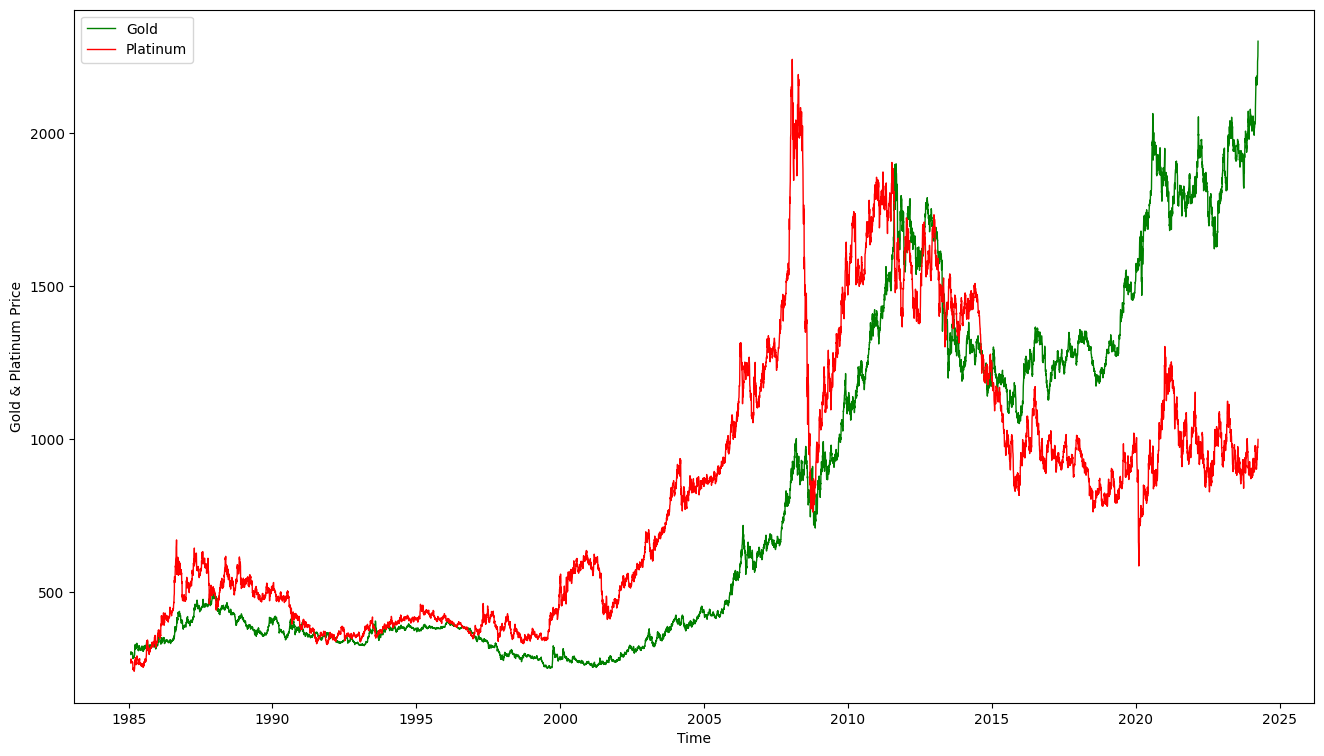

In [86]:
# Gold and Platinum Prices Plot from 1985 to 2024
plt.plot(data_set.Gold, linewidth=1, c="g", label="Gold")
plt.plot(data_set.Platinum, linewidth=1, c="r", label="Platinum")
plt.xlabel("Time")
plt.ylabel("Gold & Platinum Price")
plt.legend()
plt.show()

**Figure 22: Difference of Gold and Platinum Prices Plot from 1985 to 2024**

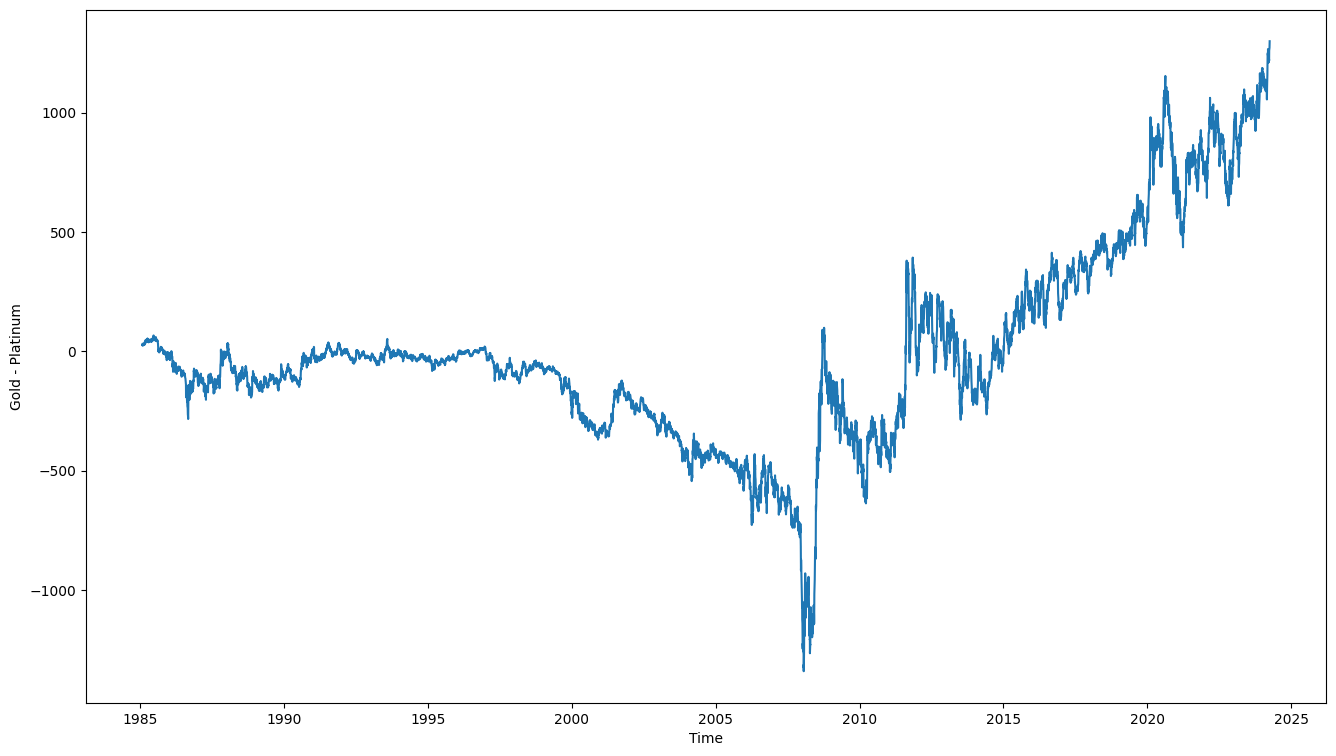

In [87]:
# Difference of Gold and PLatinum Prices Plot from 1985 to 2024
plt.plot(data_set.Gold - data_set.Platinum)
plt.xlabel("Time")
plt.ylabel("Gold - Platinum")
plt.show()

### **Engle-Granger Test for Cointegration: Gold vs Platinum**

We run an OLS model and then test the residuals for a unit root. We use Phillips and Ouliaris method and the table (PO test) to check for stationarity of residuals. The results are presented in **Figure 23** below.

**Figure 23: Two-Step Residual Based Test for Cointegration for Gold and Platinum Prices**

In [88]:
# Two-Step Residual Based Test for Cointegration for Gold and Platinum Prices
# (aka Phillips and Ouliaris cointegration test)
print(
    phillips_ouliaris(
        data_set.Gold, data_set.Platinum, trend="c", test_type="Za", kernel="bartlett"
    )
)

Phillips-Ouliaris Za Cointegration Test
Statistic: -2.8877883251603675
P-value: 0.7014965855241921
Null: No Cointegration, Alternative: Cointegration
Kernel: Bartlett
Bandwidth: 19.081
Trend: c
Distribution Order: 3


In **Figure 23**, we can see the $p$-value is greater than 0.05 critical value. Hence, we cannot reject $H_0$ and claim that the Gold and Silver prices are not cointegrated.

## **Johansen Cointegration Test: Gold, Platinum, and Silver**

Before we can use the VEC model to test for cointegration, we need to decide the number of lags in the VEC model.

**Figure 24**: Selection of Number of Lags for VEC Model

In [89]:
# Selection of Number of Lags for VEC Model
vecm_data = pd.concat(
    [data_set.Gold, data_set.Platinum, data_set.Silver], axis=1
)

# Fit VAR model and run lag selection tool
model = VAR(vecm_data)
x = model.select_order(maxlags=7, trend="c")
x.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,25.96,25.96,1.879e+11,25.96
1,7.360,7.369,1573.,7.363
2,7.356,7.371,1566.,7.361
3,7.356,7.378,1566.,7.363
4,7.173,7.201,1304.,7.182
5,7.119,7.153,1235.,7.130
6,7.101,7.142*,1214.,7.115*
7,7.100*,7.147,1212.*,7.116


**Figure 25: Johansen Trace Test Result for Gold, Platinum, and Silver Prices**

In [90]:
# Johansen Trace Test Result for Gold, Platinum, and Silver Prices

jtest = coint_johansen(vecm_data, det_order=0, k_ar_diff=1)

# Print the results
print(f"Eigenvalues of VECM coefficient matrix : {jtest.eig}\n")

pd.DataFrame(
    {
        "Test statistic": jtest.trace_stat,
        "Critical values (90%)": jtest.trace_stat_crit_vals[:, 0],
        "Critical values (95%)": jtest.trace_stat_crit_vals[:, 1],
        "Critical values (99%)": jtest.trace_stat_crit_vals[:, 2],
    },
    index=["rank=0", "rank<=1", "rank<=2"],
)

Eigenvalues of VECM coefficient matrix : [9.91116830e-03 5.73109562e-04 2.62420123e-06]



,Test statistic,Critical values (90%),Critical values (95%),Critical values (99%)
rank=0,107.187905,27.0669,29.7961,35.4628
rank<=1,5.858611,13.4294,15.4943,19.9349
rank<=2,0.026696,2.7055,3.8415,6.6349


In [91]:
# VECM model
vecm_model = VECM(endog=vecm_data, k_ar_diff=1, deterministic="ci").fit()
print(vecm_model.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation Gold
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.Gold         0.0063      0.010      0.631      0.528      -0.013       0.026
L1.Platinum    -0.0014      0.007     -0.191      0.849      -0.016       0.013
L1.Silver      -0.5198      0.328     -1.584      0.113      -1.163       0.123
Det. terms outside the coint. relation & lagged endog. parameters for equation Platinum
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.Gold         0.0442      0.013      3.292      0.001       0.018       0.070
L1.Platinum     0.0603      0.010      6.084      0.000       0.041       0.080
L1.Silver      -0.1074      0.442     -0.243      0.808      -0.974       0.760
Det. terms outside the coint

The results of the Johansen trace test are shown in **Figure 25** above. The results for the three tests are shown in the top part of **Figure 25**: $H_0$: rank = $0$, $H_0$: rank = $1$, and $H_0$: rank = $2$. Using 5% as our decision point, for $H_0$: rank = $0$ we can see the test statistic is 107.1879 and the 5% critical value is 29.7961. We reject $H_0$ and conclude that the rank is not $0$ or a cointegration relationship exists. Next, we investigate $H_0$: rank = $1$. The test statistic is 5.8586 and the 5% critical value is 15.4943. Hence, we cannot reject $H_0$: rank = $1$. Regarding $H_0$: rank = $2$. The test statistic is 0.02670 and the 5% critical value is 3.8415. Therefore, we cannot reject $H_0$: rank = $2$. This means that at least one cointegrating relationship among the three price series exists. As a result, we are justified in using a Vector Error Correction Model (VECM) instead of a VAR in differences. The coefficients of the linear combination are in the second part under '*Cointegration relations for loading-coefficients-column 1*' heading. We can write the linear combination as follows:

$$ S = -279.0847 + 1 \cdot Gold + 0.8474 \cdot Platinum -99.2085 \cdot Silver $$

The above equation is the deviation from the long-term equilibrium of the three time series. We plot it in **Figure 26** below to see if this deviation is stationary.

**Figure 26: Time Plot for Deviation from Long-term Equilibrium**

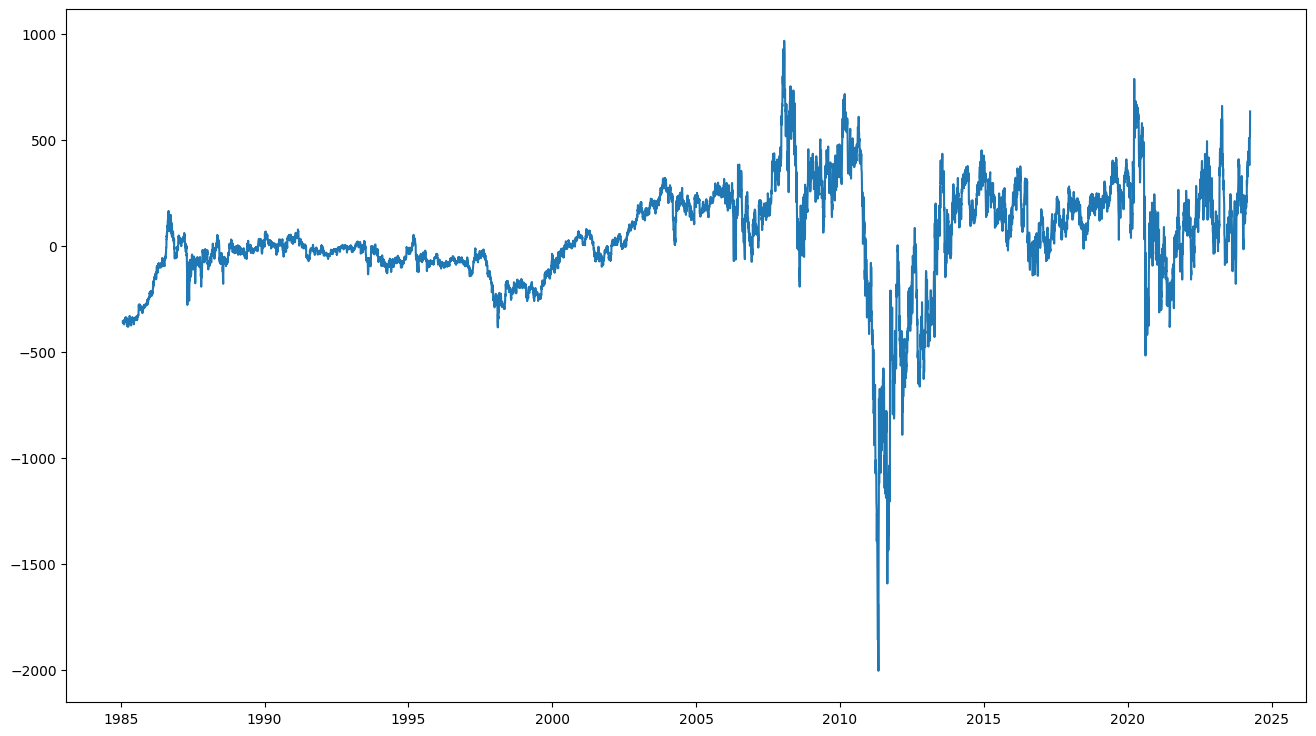

In [92]:
# Time Plot for Deviation from Long-Term Equilibrium
"""
The precise coefficients of the linear combination are in:
vecm_model.const_coint and vecm_model.beta
S = 279.0847 + 1*vecm_data.Gold + 0.8474*vecm_data.Platinum - 99.2085*vecm_data.Silver
"""
S = (
    vecm_model.const_coint[0][0]
    + vecm_model.beta[0][0] * vecm_data.Gold
    + vecm_model.beta[1][0] * vecm_data.Platinum
    + vecm_model.beta[2][0] * vecm_data.Silver
)
plt.plot(S)
plt.show()

**Figure 27: ADF Test Result for Deviation from Long-Term Equilibrium**

In [93]:
# ADF Test Result for Deviation from Long-Term Equilibrium
S_adf = ADF(S, trend="n", method="bic")
print("Augmented Dickey-Fuller Unit Root Test\n", S_adf.regression.summary())
print("\nTest statistics and critical values: \n", S_adf)

Augmented Dickey-Fuller Unit Root Test
                                  OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.056
Model:                            OLS   Adj. R-squared (uncentered):              0.053
Method:                 Least Squares   F-statistic:                              18.10
Date:                Tue, 08 Apr 2025   Prob (F-statistic):                   1.85e-101
Time:                        23:50:33   Log-Likelihood:                         -49828.
No. Observations:               10142   AIC:                                  9.972e+04
Df Residuals:                   10109   BIC:                                  9.996e+04
Df Model:                          33                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-

In **Figure 27** above, we reject that the deviation has a unit root because the test statistic (-4.469) is below the 5% critical value (-1.94).

5. **Diagnosis**: Certain critical checks are necessary to diagnose such a model of non-stationarity equilibrium. After differencing we should first perform unit root tests like the Augmented Dickey-Fuller (ADF) or KPSS test that will confirm that the transformed series are stationary. After this, we check that the residuals from the cointegrating equation are stationary, which proves the existence of a long run equilibrium. In fact, within the VECM framework we need to go one step further and test if the residuals are white noise that is they are not correlated and are not heteroskedastic using tests such as Ljung-Box Q test and ARCH test for heteroskedasticity. Furthermore, using recursive estimation methods or CUSUM tests, parameter stability can be examined in order to see that the estimated relationships remain the same over time. These diagnostic tests confirm that the model conditions are fulfilled and that the results may be relied upon for inference and prediction.
6. **Damage:** Spurious regression occurs when the non-stationarity is not modeled 𝑅2 but meaningless relationships; Greater chance of overfitting and unstable coefficients if equilibrium is ignored; Misleading forecasts and incorrect investment decisions.
7. **Directions:** If the model doesn’t fit well: Re-evaluate lag selection; Test for structural breaks (e.g., using Chow test or Bai-Perron); Consider using a Markov Switching VECM if regime shifts are suspected; Try transformations like log-differencing or seasonal adjustment.
8. **Deployment:** It can be used on various kinds of financial and economic contexts in practical applications using a cointegration based model as a Vector Error Correction Model (VECM). Its principal application is to supply a long run equilibrium relation between and thus more accurate and theoretically appropriate multi product forecasts. Pair trading, for instance, is a popular strategy where cointegrated assets such as pairs of stocks can be used to exploit mean reverting behavior of prices: Buy the undervalued one in hopes that its price will increase, and sell the overvalued one with an expectation that its price will fall. The model gives insight into the dynamics of asset relationships under stress and can provide signals of possible systemic risk ahead of time by showing deviations from equilibrium. Furthermore, they are widely used in policy analysis by economists and central banks, as a means to evaluate the long run effects of policy interventions, as in the case of interest rate changes, on key macroeconomic indicators, particularly on inflation and exchange rates. The overall deployment of such models is beneficial for data driven decision making from both the short term noise and the long term equilibrium behavior of the financial time series.


## Challenge 3: Handling multicollinearity

1. **Definition:** Multicollinearity is the occurrence of high intercorrelations among two or more independent variables in a multiple regression model. The multiple linear regression model with multicollinearity is represented as:
\begin{equation}
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon
\end{equation}
where
\begin{equation} X_1 \end{equation} and \begin{equation} X_2 \end{equation}  are highly correlated, leading to instability in estimating \begin{equation} \beta_1 \end{equation} and \begin{equation} \beta_2 \end{equation}

2. **Description**: When predictor variables in a regression model are heavily correlated, multicollinearity is said to occur and it makes it hard to tease out each predictor’s unique effect; this can result in unstable coefficient estimates, but it does not necessarily affect the model’s predictive power.

3. **Demonstration:** We used daily returns of Apple (AAPL), Google (GOOGL), Amazon (AMZN) and Microsoft (MSFT) stocks (Oct 2022-Jan 2023) because tech sector stocks often exhibit high correlation, creating multicollinearity.

In [94]:
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [95]:
# Financial data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
start_date = '2022-10-01'
end_date = '2023-01-01'

# Adjusted closing prices
data = yf.download(tickers, start=start_date, end=end_date)
data = data['Close']

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


In [96]:
# Daily return
returns = data.pct_change().dropna()
returns.columns = tickers

In [97]:
# Correlation
corr_matrix = returns.corr()
print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
            AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000  0.657548  0.825142  0.847375
MSFT   0.657548  1.000000  0.727987  0.741968
GOOGL  0.825142  0.727987  1.000000  0.912659
AMZN   0.847375  0.741968  0.912659  1.000000


In [98]:
# Variance Inflation Factor
vif_data = pd.DataFrame()
vif_data["Variable"] = returns.columns
vif_data["VIF"] = [variance_inflation_factor(returns.values, i) for i in range(returns.shape[1])]

print("\nVIF Results:\n", vif_data)


VIF Results:
   Variable       VIF
0     AAPL  3.761510
1     MSFT  2.262714
2    GOOGL  6.495296
3     AMZN  7.301752


Among GOOGL and AMZN there were large multicollinearity issues, that are due to their high correlation measure (0.913) and high Variance Inflation Factor (VIF) values of 6.50 and 7.30, respectively which exceeds the threshold of 5. The near identical behavior of these univariate variables from a box plot suggests redundancy as predictors in a regression model, as their inclusion in a regression model causes standard errors to become excessive and coefficient estimates to become unstable. However, notwithstanding strong pairwise correlation, AAPL (VIF: 3.76) and MSFT (VIF: 2.26) still fall within acceptable multicollinearity limits, convergent with other tech stocks having to move together.

4. **Diagram:** We plotted differents diagrams
- **Correlation Heatmap:**
We can visualize pairwise correlations to identify strongly related variables.

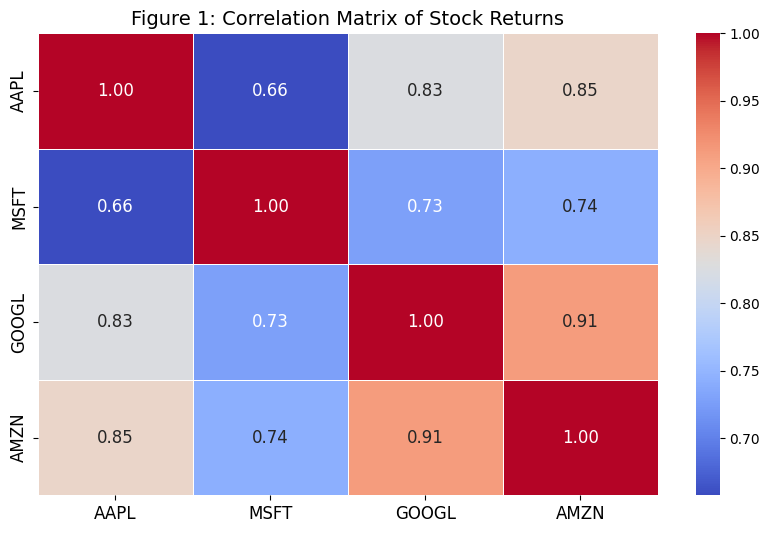

In [99]:
# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 12}
)
plt.title("Figure 1: Correlation Matrix of Stock Returns", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

AMZN-GOOGL and AMZN-AAPL show the strongest correlations.

- **Variance Inflation Factor (VIF) Bar Plot:** We can visualize VIF scores to quantify multicollinearity.

<ipython-input-100-432cd43c45cb>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


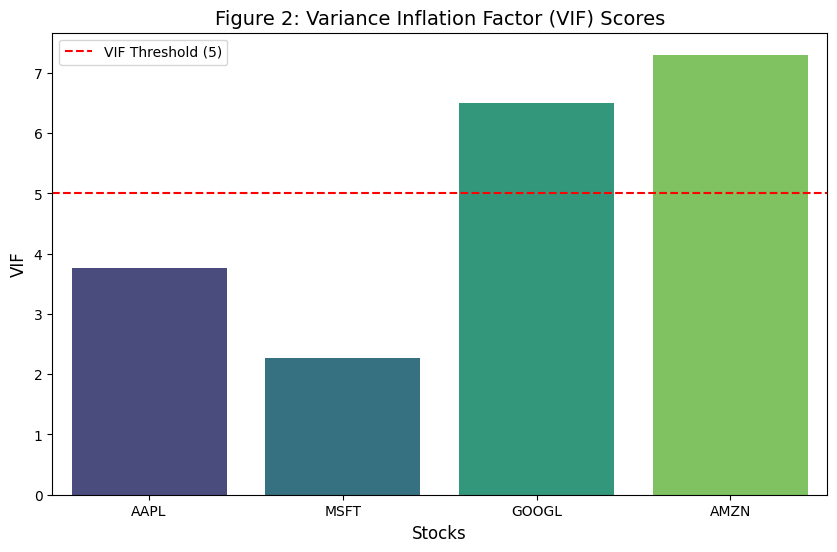

In [100]:
# Plot VIF
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Variable",
    y="VIF",
    data=vif_data,
    palette="viridis"
)
plt.axhline(y=5, color='red', linestyle='--', label="VIF Threshold (5)")
plt.title("Figure 2: Variance Inflation Factor (VIF) Scores", fontsize=14)
plt.xlabel("Stocks", fontsize=12)
plt.ylabel("VIF", fontsize=12)
plt.legend()
plt.show()

AMZN and GOOGL exceed the VIF threshold.
These variables introduce multicollinearity and should be addressed.

- **Pair Plot:** We can visualize pairwise relationships for deeper exploration.

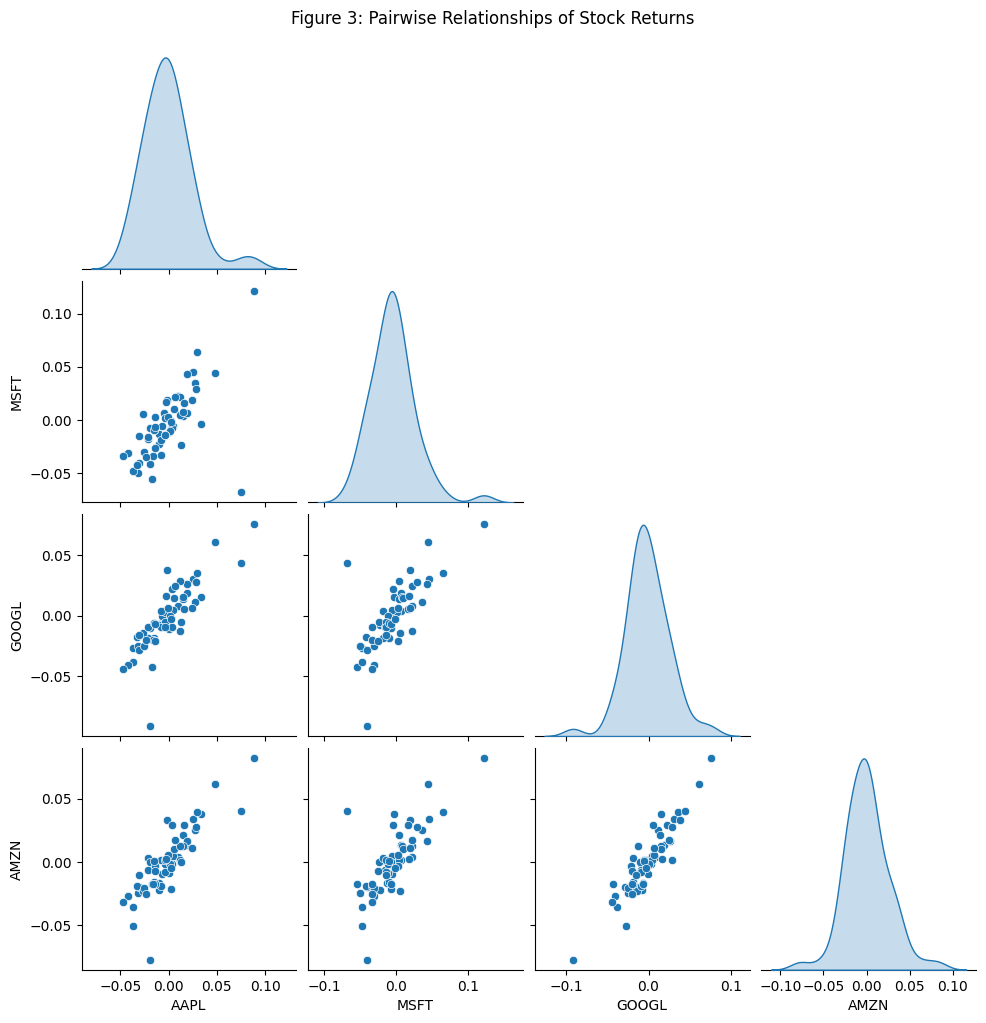

In [101]:
# Pairplot
sns.pairplot(returns, diag_kind='kde', corner=True)
plt.suptitle("Figure 3: Pairwise Relationships of Stock Returns", y=1.02)
plt.show()

Diagonal plots show return distributions and scatterplots confirm linear relationships.

5. **Diagnosis:** Pairwise correlations can be used to diagnose multicollinearity, but high correlations on their own do not indicate how complex the interdependencies among many predictors are. Variance Inflation Factors (VIFs) measure the degree to which a predictor’s coefficient variance is inflated by that linear relationship with other variables, given that VIF > 1 implies some inflation (values of 5–10 or higher suggest severe problems). Variance ratios of components from the principal component analysis (PCA) indicate collinearity and indices >30 indicate redundancy. Moreover, the unstable coefficient estimates or seemingly counterintuitive signs when adding or removing predictors can be a mark that multicollinearity is present.
<br>As we already saw how Correlation Heatmap, VIP Barplot and Pairplot operate, let's see advanced plots.


- **Clustered Heatmap:**
Groups variables by correlation strength.

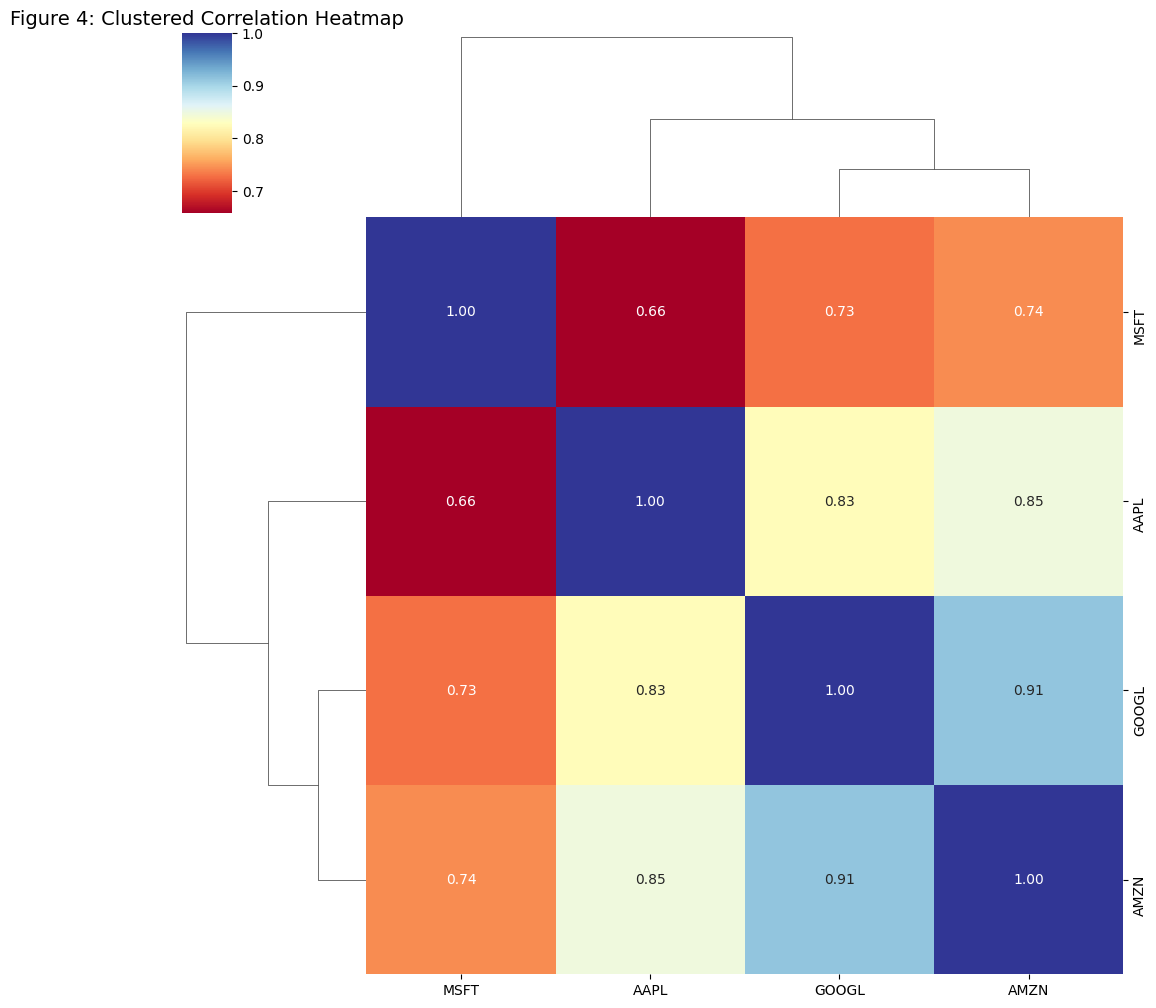

In [102]:
# Cluster variables hierarchically
sns.clustermap(returns.corr(), cmap="RdYlBu", annot=True, fmt=".2f", figsize=(10, 10))
plt.title("Figure 4: Clustered Correlation Heatmap", fontsize=14)
plt.show()

AMZN and GOOGL cluster together, confirming their redundancy.
AAPL is closer to this cluster than MSFT, aligning with correlation values.

- **PCA Biplot:**
Visualizes multicollinear variables in reduced dimensions.

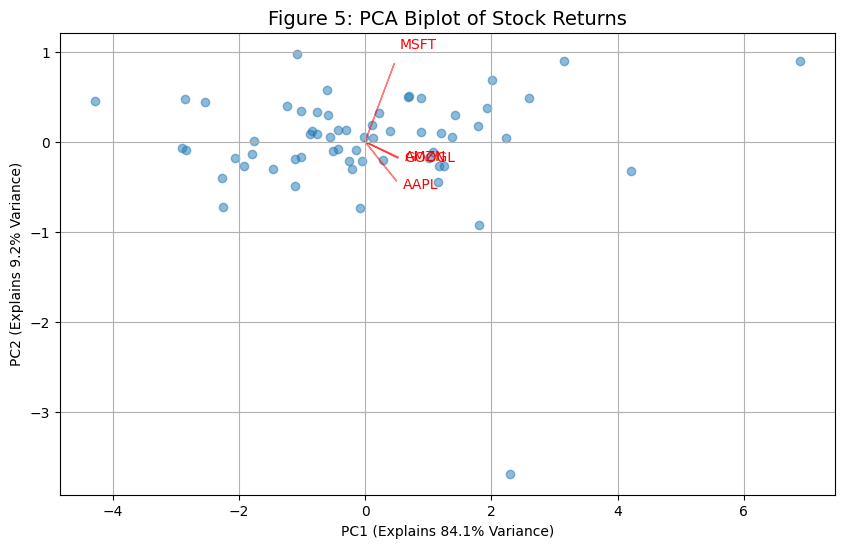

In [103]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize data
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns)

# Fit PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_returns)

# Biplot
plt.figure(figsize=(10, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)
for i, feature in enumerate(returns.columns):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i], color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*1.2, pca.components_[1, i]*1.2, feature, color='r')

plt.xlabel("PC1 (Explains {:.1f}% Variance)".format(pca.explained_variance_ratio_[0]*100))
plt.ylabel("PC2 (Explains {:.1f}% Variance)".format(pca.explained_variance_ratio_[1]*100))
plt.title("Figure 5: PCA Biplot of Stock Returns", fontsize=14)
plt.grid()
plt.show()

AMZN and GOOGL overlap in direction confirming collinearity.
PCA can merge them into a single component.

6. **Damage:** It observes high Variance Inflation Factors for AMZN and GOOGL that cause coefficients of regressors to be inflated, estimates are destabilized, and the effects of each regressor obscure. This redundancy introduces interpretational ambiguity as well as high sensitivity to data changes, which makes the model not be reliable. In addition to multicollinearity diagnostics, to evaluate overall quality, one needs to complement: overfitting (cross validation), heteroscedasticity (residual analysis), non-linearity (curvature checks), outliers (Cook’s distance), and (Q-Q) plots for non normal residuals. To make a robust, interpretable model that accurately captures relationships in the financial data and to avoid instability, one can address these problems, especially by removing variables, if it is possible by PCA or regularization.

7. **Directions:** For the balance part, we need to address whether data manipulation should be the one used to improve model fit. Adjusting data can solve multicollinearity or non-stationarity in data, but that may lead to overfitting or losing some necessary market context. Even if such extreme points are truly extreme, removing them and not handling such points with robust methods such as regularization is not advisable. Therefore, outliers should be removed only if they are data errors. Rather than being aggressive in manipulating the data, favor model improvements—like Ridge/Lasso regression to ensure stability, merging collinear variables via PCA, feature engineering —to retain the purity of your data. It must be validated rigorously with cross validation or out of sample testing in order to ensure generalizability.

8. **Deployment:** Finally, we deploy the financial model well by making their training data clean of redundant variables such as AMZN and GOOGL and either removing the redundant variables into a single "Tech Sector" or merging them by conducting PCA. This ensures stable, interpretable predictions. Then, the model is integrated to a cloud based infrastructure where actual live time stock data is fetched, processed and stored securely. It is hosted as an API for straight code into automated trading systems or risk management dashboards. Using user friendly interfaces, analysts can interface with predictions and are alerted to such critical signals as sudden volatility. De provides regular monitoring of the accuracy and data drift which automatically retrain to adapt the market shifts. Sensitive data is protected through measures such as encryption and role based access, compliance protocols are followed to be transparent and accountable. By being practical but technically sound the model acts as a trusted, real time framework for making informed, real time financial decisions.

Work Cited
<br>Ciaburro, G., & Iannace, G. (2021). Machine learning-based algorithms to knowledge extraction from time series data: A review. Data, 6(6), 55.
<br>Dagum, E. B., & Bianconcini, S. (2016). Seasonal adjustment methods and real-time trend-cycle estimation. Berlin/Heidelberg, Germany: Springer International Publishing.
<br>“Multicollinearity.” Wikipedia, Wikimedia Foundation, 16 June 2024, en.wikipedia.org/wiki/Multicollinearity. Accessed 04 Avr. 2025.
<br>“Multicollinearity.” Investopedia, Dotdash Meredith, www.investopedia.com/terms/m/multicollinearity.asp. Accessed 04 Avr. 2025.
<br>DataCamp Team. “Multicollinearity.” DataCamp, n.d., www.datacamp.com/tutorial/multicollinearity. Accessed 04 Avr. 2025.
<br>Cornell Statistical Consulting Unit. Multicollinearity. Cornell University, n.d., cscu.cornell.edu/wp-content/uploads/multco.pdf. Accessed 04 Avr. 2025.
<br>Alexander, Carol. Market Models: A Guide to Financial Data Analysis. John Wiley & Sons Ltd, 2001.
<br>———. Market Risk Analysis: Volume 1, Quantitative Methods in Finance. John Wiley & Sons Ltd, 2008.
<br>Gourieroux, Christian, and Joann Jasiak. Financial Econometrics. Princeton University Press, 2001.
